## 1. Importar herramientas

In [1]:
import csv
import re
import unicodedata
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 70)

RANDOM_STATE = 42
GUARDAR_FIGURAS = True   # guarda las figuras en reports/figures/

## 2. Cargar el dataset

Se prueban varias codificaciones y se detecta el separador, porque los CSV del Estado no siempre vienen en UTF-8 ni con coma.

In [2]:
def encontrar_raiz():
    p = Path.cwd().resolve()
    for c in [p, *p.parents]:
        if (c / "data").is_dir() and (c / "src").is_dir():
            return c
    raise FileNotFoundError("No se encontró la raíz del proyecto (carpetas data/ y src/).")


def cargar_dataset(ruta):
    tipos = {"NRO_DOCUMENTO": str, "FECHA_INICIO": str, "FECHA_TERMINO": str}
    for enc in ("utf-8-sig", "cp1252", "latin-1"):
        try:
            with open(ruta, encoding=enc, errors="replace") as f:
                muestra = f.read(20000)
            try:
                sep = csv.Sniffer().sniff(muestra, delimiters=",;\t|").delimiter
            except csv.Error:
                sep = ","
            return pd.read_csv(ruta, encoding=enc, sep=sep, dtype=tipos, low_memory=False), enc, sep
        except UnicodeDecodeError:
            continue
    raise ValueError("No se pudo decodificar el archivo.")


ROOT = encontrar_raiz()
RUTA = ROOT / "data" / "raw" / "Dataset_ENAP_RSCC_Dic_2025_May_2026.csv"
CARPETA_FIGURAS = ROOT / "reports" / "figures"
if not RUTA.exists():
    raise FileNotFoundError(f"No existe {RUTA}\nEjecuta primero: python src/utils/download_data.py")

df, ENCODING, SEPARADOR = cargar_dataset(RUTA)
df.columns = df.columns.str.strip().str.upper()
print(f"Leído con encoding={ENCODING!r} y separador {SEPARADOR!r} · dimensiones: {df.shape}")
df.head()

Leído con encoding='utf-8-sig' y separador ';' · dimensiones: (83930, 20)
Out[2]: 
   NRO DEPARTAMENTO PROVINCIA           DISTRITO  ANO_CAPACITACION  \
0    1       LORETO    MAYNAS  SAN JUAN BAUTISTA              2025   
1    2       CALLAO    CALLAO             CALLAO              2025   
2    3        PIURA   AYABACA            LAGUNAS              2025   
3    4         LIMA      LIMA        JESÚS MARÍA              2025   
4    5     AYACUCHO  HUAMANGA           AYACUCHO              2025   

             AREA TIPO_DOCUMENTO NRO_DOCUMENTO          BENEFICIARIO    SEXO  \
0  IMPLEMENTACIÓN            DNI     *********  ********************  HOMBRE   
1  IMPLEMENTACIÓN            DNI     *********  ********************   MUJER   
2  IMPLEMENTACIÓN            DNI     *********  ********************   MUJER   
3  IMPLEMENTACIÓN            DNI     *********  ********************   MUJER   
4  IMPLEMENTACIÓN            DNI     *********  ********************   MUJER   

  NIVEL_GOBIERN

## 3. Preguntas que guían el EDA


Salen de `docs/definicion-problema.md`:

| # | Pregunta | Dónde |
|---|---|---|
| P1 | ¿Qué proporción culmina y qué proporción cae en riesgo, y cómo cambia según tipo de capacitación, modalidad y nivel de gobierno? | Bloques 1 y 2 |
| P2 | ¿Hay diferencias de riesgo entre sexo, departamento y tipo de convocatoria? | Bloque 2 |
| P3 | ¿Cuánto depende el resultado de la capacitación y cuánto del participante? | Bloque 3 |
| P4 | ¿Qué problemas de calidad y qué variables pueden filtrar el resultado? | Bloque 4 |

## 4. Preparar una copia para explorar


`df_temp` es una copia con arreglos mínimos: texto sin espacios de más y en mayúsculas, horas como número, fechas como fechas, la duración en días y una 'clave de edición' (nombre + fechas + modalidad). La clave hace falta porque el archivo no trae un identificador de capacitación, y los participantes de una misma edición comparten resultado en buena parte.

También se crea `y`: 1 si terminó `DESAPROBADO` o `RETIRADO`, 0 si terminó `APROBADO` o `ASISTIÓ`.

In [3]:
sin_normalizar = ("NRO_DOCUMENTO", "BENEFICIARIO", "FECHA_INICIO", "FECHA_TERMINO")
cols_texto = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c]) and c not in sin_normalizar]

df_temp = df.copy()
for c in cols_texto:
    df_temp[c] = df_temp[c].str.strip().str.replace(r"\s+", " ", regex=True).str.upper()

df_temp["ESTADO"] = df_temp["ESTADO_CAPACITACION"]
df_temp["y"] = df_temp["ESTADO"].isin(["DESAPROBADO", "RETIRADO"]).astype(int)
df_temp["HORAS_NUM"] = pd.to_numeric(df_temp["HORAS_ACADEMICAS"], errors="coerce")
df_temp["ANO_NUM"] = pd.to_numeric(df_temp["ANO_CAPACITACION"], errors="coerce")
df_temp["INICIO"] = pd.to_datetime(df_temp["FECHA_INICIO"], format="%Y%m%d", errors="coerce")
df_temp["TERMINO"] = pd.to_datetime(df_temp["FECHA_TERMINO"], format="%Y%m%d", errors="coerce")
df_temp["DURACION_DIAS"] = (df_temp["TERMINO"] - df_temp["INICIO"]).dt.days
df_temp["MES_INICIO"] = df_temp["INICIO"].dt.strftime("%Y-%m")
df_temp["EDICION"] = (df_temp["NOMBRE_CAPACITACION"].astype(str) + " | " + df_temp["FECHA_INICIO"].astype(str)
                      + " | " + df_temp["FECHA_TERMINO"].astype(str) + " | " + df_temp["MODALIDAD"].astype(str))

print("Ediciones distintas:", df_temp["EDICION"].nunique())
print("Fechas no interpretables:", int(df_temp["INICIO"].isna().sum() + df_temp["TERMINO"].isna().sum()))

Ediciones distintas: 379
Fechas no interpretables: 0


Funciones auxiliares que se usarán a lo largo del notebook.

In [4]:
def etiquetas(indice):
    return ["(vacío)" if pd.isna(i) else str(i) for i in indice]


def guardar(nombre):
    if GUARDAR_FIGURAS:
        CARPETA_FIGURAS.mkdir(parents=True, exist_ok=True)
        plt.savefig(CARPETA_FIGURAS / f"{nombre}.png", bbox_inches="tight", dpi=150)


def normalizar_texto(s):
    s = unicodedata.normalize("NFKD", str(s))
    s = "".join(c for c in s if not unicodedata.combining(c))
    return re.sub(r"\s+", " ", s).strip().upper()


def wilson(k, n, z=1.96):
    # intervalo de confianza (95 %) para una proporción k/n
    k, n = np.asarray(k, float), np.asarray(n, float)
    with np.errstate(divide="ignore", invalid="ignore"):
        p = k / n
        den = 1 + z**2 / n
        centro = (p + z**2 / (2 * n)) / den
        mitad = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return centro - mitad, centro + mitad


def tabla_tasas(d, col, min_n=1):
    g = d.groupby(col, dropna=False)["y"].agg(n="size", k="sum")
    g["tasa"] = g["k"] / g["n"]
    g["ic_inf"], g["ic_sup"] = wilson(g["k"], g["n"])
    return g[g["n"] >= min_n].sort_values("n", ascending=False)


def graficar_tasas(d, col, top=10, min_n=30, ax=None):
    t = tabla_tasas(d, col, min_n).head(top).sort_values("tasa")
    nombres = [f"{x[:32]} (n={int(n):,})" for x, n in zip(etiquetas(t.index), t["n"])]
    ax.barh(nombres, t["tasa"], color="#4C72B0", capsize=3, ecolor="#333",
            xerr=[t["tasa"] - t["ic_inf"], t["ic_sup"] - t["tasa"]])
    ax.axvline(TASA_GLOBAL, ls="--", color="crimson", lw=1.2, label=f"Global {TASA_GLOBAL:.1%}")
    ax.set_title(col, fontsize=10)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.tick_params(axis="y", labelsize=8)
    ax.legend(fontsize=8, loc="lower right")


def graficar_tasas_ordenadas(d, serie, titulo, ax, min_n=30):
    t = d.assign(_g=serie).groupby("_g")["y"].agg(n="size", k="sum")
    t = t[t["n"] >= min_n]
    t["tasa"] = t["k"] / t["n"]
    t["ic_inf"], t["ic_sup"] = wilson(t["k"], t["n"])
    x = np.arange(len(t))
    ax.errorbar(x, t["tasa"], yerr=[t["tasa"] - t["ic_inf"], t["ic_sup"] - t["tasa"]], fmt="o-", capsize=3, color="#4C72B0")
    ax.axhline(TASA_GLOBAL, ls="--", color="crimson", lw=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels([str(i)[:14] for i in t.index], rotation=45, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_title(titulo, fontsize=10)


def discretizar(s, max_niveles=40, q=10):
    if s.nunique() <= max_niveles:
        return s
    return pd.qcut(s, q=q, duplicates="drop").astype(str).where(s.notna())


def asociacion(d, col):
    # % de la variación del resultado asociada a los grupos de `col`, y cuánto saldría solo por azar
    g = d.groupby(col, dropna=False)["y"].agg(["size", "mean"])
    if len(g) < 2:
        return np.nan, np.nan, len(g)
    p = d["y"].mean()
    ss_entre = (g["size"] * (g["mean"] - p) ** 2).sum()
    return ss_entre / (len(d) * p * (1 - p)), (len(g) - 1) / (len(d) - 1), len(g)

# BLOQUE 1 - PANORAMA GENERAL

## 5. Variable objetivo

Pregunta: **¿qué proporción culmina y qué proporción cae en riesgo?**

Riesgo (desaprobado + retirado): 2,170 registros = 2.59%
Un modelo que siempre diga 'sin riesgo' acertaría 97.4% sin detectar a nadie.


,registros,%
ESTADO,,
ASISTIÓ,47249,56.30
APROBADO,34511,41.12
DESAPROBADO,2060,2.45
RETIRADO,110,0.13


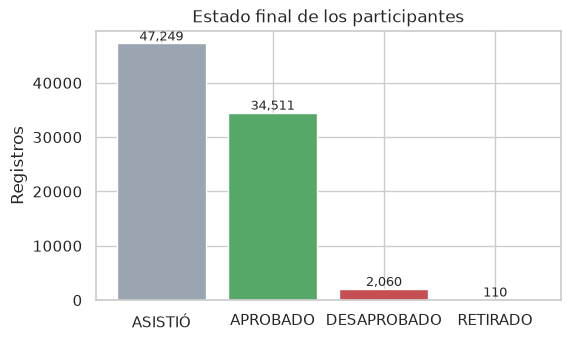

In [5]:
ORDEN = [e for e in ["ASISTIÓ", "APROBADO", "DESAPROBADO", "RETIRADO"] if e in df_temp["ESTADO"].unique()]
COLORES = {"ASISTIÓ": "#9AA5B1", "APROBADO": "#55A868", "DESAPROBADO": "#C44E52", "RETIRADO": "#DD8452"}

conteo = df_temp["ESTADO"].value_counts().reindex(ORDEN)
display(pd.DataFrame({"registros": conteo, "%": (conteo / conteo.sum() * 100).round(2)}))

plt.figure(figsize=(6, 3.5))
plt.bar(ORDEN, conteo.values, color=[COLORES[e] for e in ORDEN])
for i, v in enumerate(conteo.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.title("Estado final de los participantes")
plt.ylabel("Registros")
guardar("01_estado_final")
plt.show()

tasa_global_todo = df_temp["y"].mean()
print(f"Riesgo (desaprobado + retirado): {df_temp['y'].sum():,} registros = {tasa_global_todo:.2%}")
print(f"Un modelo que siempre diga 'sin riesgo' acertaría {1 - tasa_global_todo:.1%} sin detectar a nadie.")

56 % de los registros son ASISTIÓ y 41 % APROBADO. Solo 2060 desaprobaron (2.5 %) y 110 se retiraron (0.1 %), el riesgo total es 2.6 %.

- Un modelo que siempre diga 'sin riesgo' acertaría 97.4 % sin detectar a nadie, así que el porcentaje de aciertos no sirve acá. Lo que importa es cuántos casos de riesgo se detectan y cuántas alertas son correctas.

## 6. ¿Se puede "fallar" en todas las capacitaciones?

Pregunta: **¿cómo cambia el estado final según el tipo de capacitación?** (P1)

ESTADO,ASISTIÓ,APROBADO,DESAPROBADO,RETIRADO,registros,riesgo_%
TIPO_CAPACITACION,,,,,,
EVENTO ACADÉMICO,44357,0,0,0,44357,0.0
CURSO MOOC,0,21107,1221,0,22328,5.5
TALLER,2892,3077,497,20,6486,8.0
PROGRAMA,0,5528,106,82,5716,3.3
CURSO,0,3841,103,5,3949,2.7
MICROCURSO,0,902,128,0,1030,12.4
INNOVATHON,0,56,5,3,64,12.5


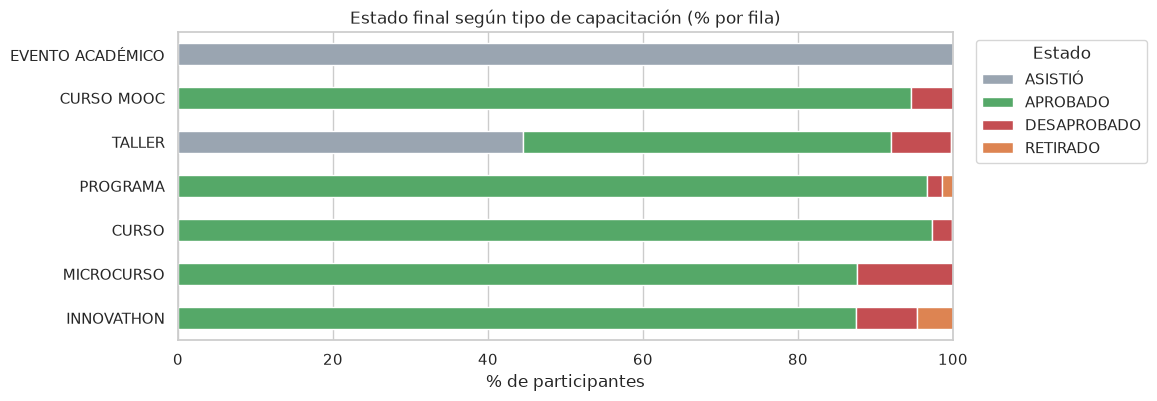

In [6]:
tab = pd.crosstab(df_temp["TIPO_CAPACITACION"], df_temp["ESTADO"])[ORDEN]
tab["registros"] = tab.sum(axis=1)
tab["riesgo_%"] = ((tab.get("DESAPROBADO", 0) + tab.get("RETIRADO", 0)) / tab["registros"] * 100).round(1)
display(tab.sort_values("registros", ascending=False))

pct = pd.crosstab(df_temp["TIPO_CAPACITACION"], df_temp["ESTADO"], normalize="index")[ORDEN] * 100
pct = pct.loc[tab.sort_values("registros").index]
pct.plot(kind="barh", stacked=True, figsize=(10, 4), color=[COLORES[e] for e in ORDEN])
plt.title("Estado final según tipo de capacitación (% por fila)")
plt.xlabel("% de participantes")
plt.ylabel("")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Estado")
guardar("02_estado_por_tipo")
plt.show()

Los eventos académicos (44 mil registros, más de la mitad del dataset) son todos ASISTIÓ: ahí nadie desaprueba ni se retira. ASISTIÓ solo aparece en eventos y en parte de los talleres. En los demás tipos el riesgo va de ~3 % (cursos y programas) a ~12 % (microcursos e innovathon).

Más de la mitad del dataset no puede "fallar" por diseño, así que el 2.6 % global está diluido. Si el modelo aprende que evento = sin riesgo», parecerá bueno sin aportar nada. Eso se debe considerar en etapas futuras.

Para confirmarlo, clasificamos cada **edición** según los estados que tiene: *solo asistencia*, *con evaluación* (aprobado, desaprobado o retirado) o *mixta*. La población de análisis será la de ediciones **con evaluación**, que son las únicas donde se puede desaprobar.

In [7]:
SOLO_EVALUABLES = True   # False = usar todos los registros

est_ed = pd.crosstab(df_temp["EDICION"], df_temp["ESTADO"])
asiste = est_ed["ASISTIÓ"] > 0 if "ASISTIÓ" in est_ed else pd.Series(False, index=est_ed.index)
evalua = est_ed.drop(columns=["ASISTIÓ"], errors="ignore").sum(axis=1) > 0
regimen = pd.Series(np.select([asiste & ~evalua, ~asiste & evalua, asiste & evalua],
                              ["Solo asistencia", "Con evaluación", "Mixta"], default="Otro"), index=est_ed.index)
df_temp["REGIMEN"] = df_temp["EDICION"].map(regimen)

resumen = df_temp.groupby("REGIMEN").agg(ediciones=("EDICION", "nunique"), registros=("y", "size"), riesgo=("y", "sum"))
resumen["riesgo_%"] = (resumen["riesgo"] / resumen["registros"] * 100).round(2)
display(resumen)

df_eval = df_temp[df_temp["REGIMEN"] == "Con evaluación"].copy() if SOLO_EVALUABLES else df_temp.copy()
TASA_GLOBAL = df_eval["y"].mean()
print(f"Población de análisis: {len(df_eval):,} registros ({len(df_eval) / len(df_temp):.0%} del total) · riesgo = {TASA_GLOBAL:.2%}")

Población de análisis: 36,681 registros (44% del total) · riesgo = 5.92%


,ediciones,registros,riesgo,riesgo_%
REGIMEN,,,,
Con evaluación,198,36681,2170,5.92
Solo asistencia,181,47249,0,0.00


Las ediciones se separan en "solo asistencia" y "con evaluación". Mirando solo las que se evalúan, el riesgo sube a cerca de 6 %.

El modelo debería trabajar solo con ediciones donde sí se puede desaprobar.

## 7. Panorama de las demás variables

Lima: 40.4% · Mujeres: 53.0%


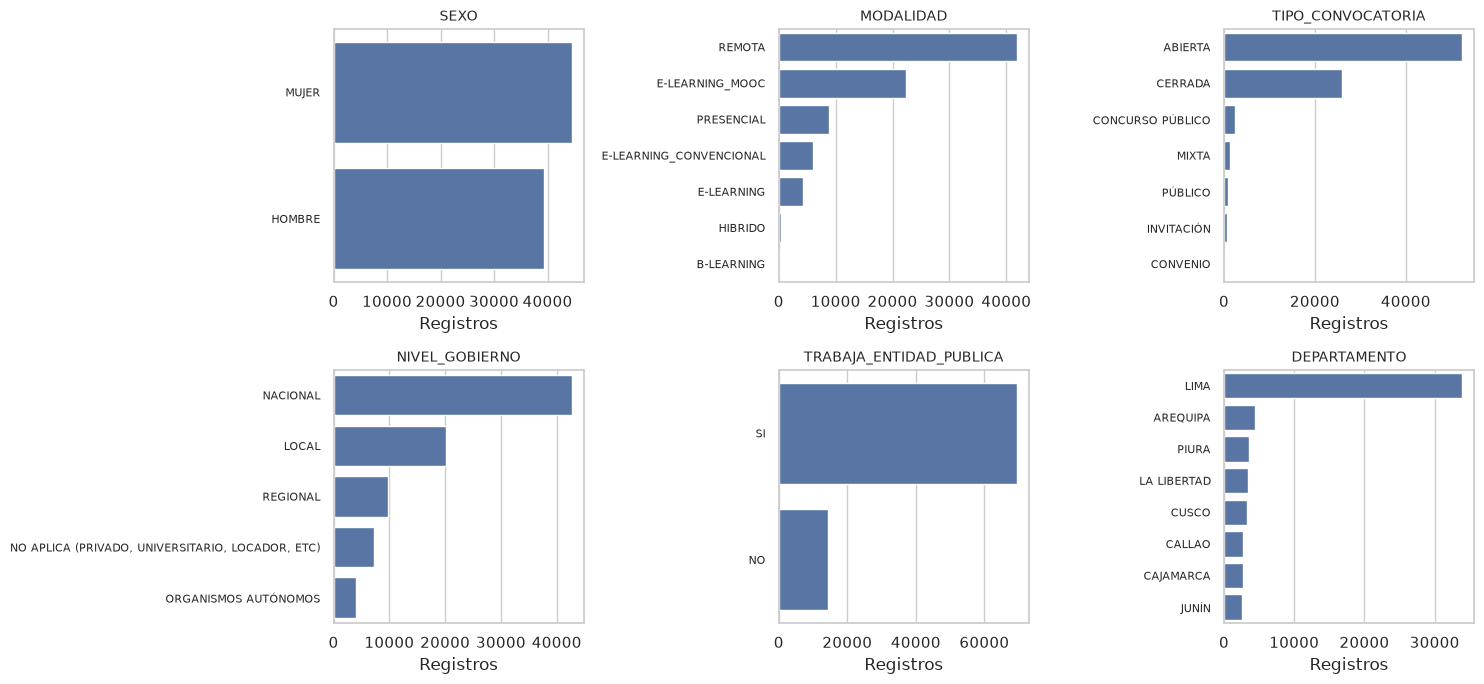

In [8]:
cols = ["SEXO", "MODALIDAD", "TIPO_CONVOCATORIA", "NIVEL_GOBIERNO", "TRABAJA_ENTIDAD_PUBLICA", "DEPARTAMENTO"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), cols):
    orden = df_temp[col].value_counts().head(8).index
    sns.countplot(data=df_temp, y=col, order=orden, ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Registros")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
guardar("03_panorama_variables")
plt.show()
print(f"Lima: {(df_temp['DEPARTAMENTO'] == 'LIMA').mean():.1%} · Mujeres: {(df_temp['SEXO'] == 'MUJER').mean():.1%}")

Hay más mujeres (53 %), la modalidad más común es REMOTA (~50 %), la convocatoria más común es ABIERTA (62 %) y 40 % de las personas están en Lima.

Casi todas las variables tienen una categoría que domina, y buena parte de lo "remoto" son eventos.

## 8. Horas de las capacitaciones

Pregunta: **¿cuánto duran y cómo se relaciona con el estado final?**

Mediana: 3 h - Registros de 2 horas: 45%
Out[9]: 
             count  median  max
ESTADO                         
ASISTIÓ      47249     2.0   16
APROBADO     34511    24.0  234
DESAPROBADO   2060    24.0  234
RETIRADO       110   198.0  234


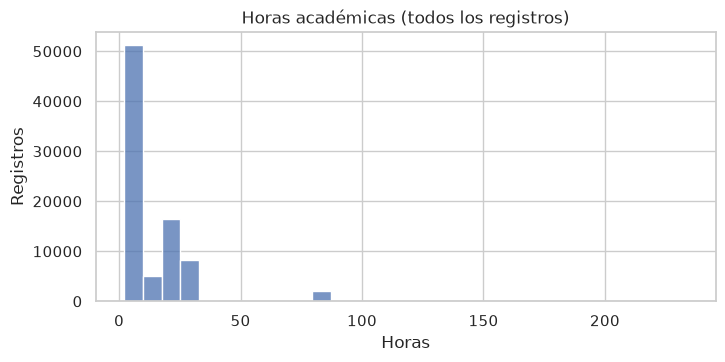

In [9]:
plt.figure(figsize=(8, 3.5))
sns.histplot(df_temp["HORAS_NUM"], bins=30)
plt.title("Horas académicas (todos los registros)")
plt.xlabel("Horas")
plt.ylabel("Registros")
guardar("04_horas")
plt.show()

print(f"Mediana: {df_temp['HORAS_NUM'].median():.0f} h - Registros de 2 horas: {(df_temp['HORAS_NUM'] == 2).mean():.0%}")
df_temp.groupby("ESTADO")["HORAS_NUM"].agg(["count", "median", "max"]).reindex(ORDEN)

La mayoría de actividades dura muy poco: la mediana es 3 horas y 45 % de los registros son de 2 horas (eventos). Los retirados vienen casi siempre de programas largos (mediana ~200 horas); aprobados y desaprobados tienen horas parecidas (mediana 24).

Las horas ayudan a distinguir quién se retira (programas largos), pero poco a distinguir quién desaprueba.

## 9. Fechas

Pregunta: **¿de qué período son realmente las capacitaciones?**

FECHA_INICIO : 2025-02-17 -> 2026-05-07
FECHA_TERMINO: 2015-12-01 -> 2026-05-17


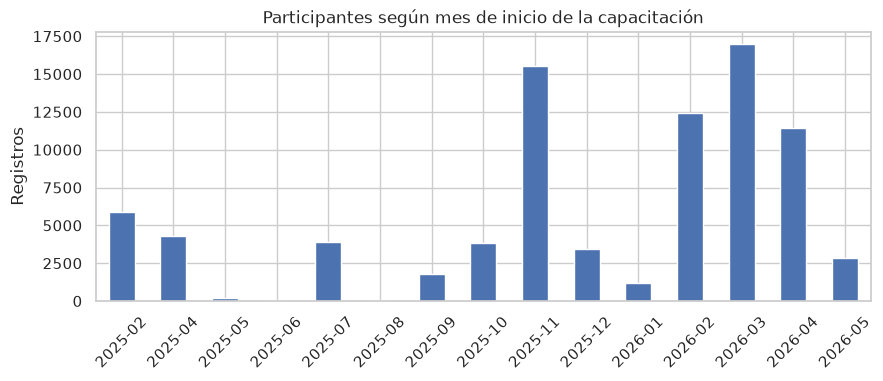

In [10]:
print("FECHA_INICIO :", df_temp["INICIO"].min().date(), "->", df_temp["INICIO"].max().date())
print("FECHA_TERMINO:", df_temp["TERMINO"].min().date(), "->", df_temp["TERMINO"].max().date())

plt.figure(figsize=(10, 3.5))
df_temp["MES_INICIO"].value_counts().sort_index().plot(kind="bar", color="#4C72B0")
plt.title("Participantes según mes de inicio de la capacitación")
plt.xlabel("")
plt.ylabel("Registros")
plt.xticks(rotation=45)
guardar("05_mes_inicio")
plt.show()

Las capacitaciones empiezan entre feb-2025 y may-2026, con picos en nov-2025 y feb–abr 2026. Una fecha de término cae en 2015, lo cual sugiere que puede ser un error evidente de digitación.

Dic 2025 – May 2026 parece ser la ventana del reporte y no las fechas de los cursos.

# BLOQUE 2 - RIESGO SEGÚN GRUPOS

De aquí en adelante se usa la población de análisis (`df_eval`): ediciones donde sí se puede desaprobar. La línea roja es el riesgo promedio.

## 10. Tipo de capacitación, modalidad y nivel de gobierno

Pregunta: **¿cambia el riesgo según el formato del curso y el nivel de gobierno?**

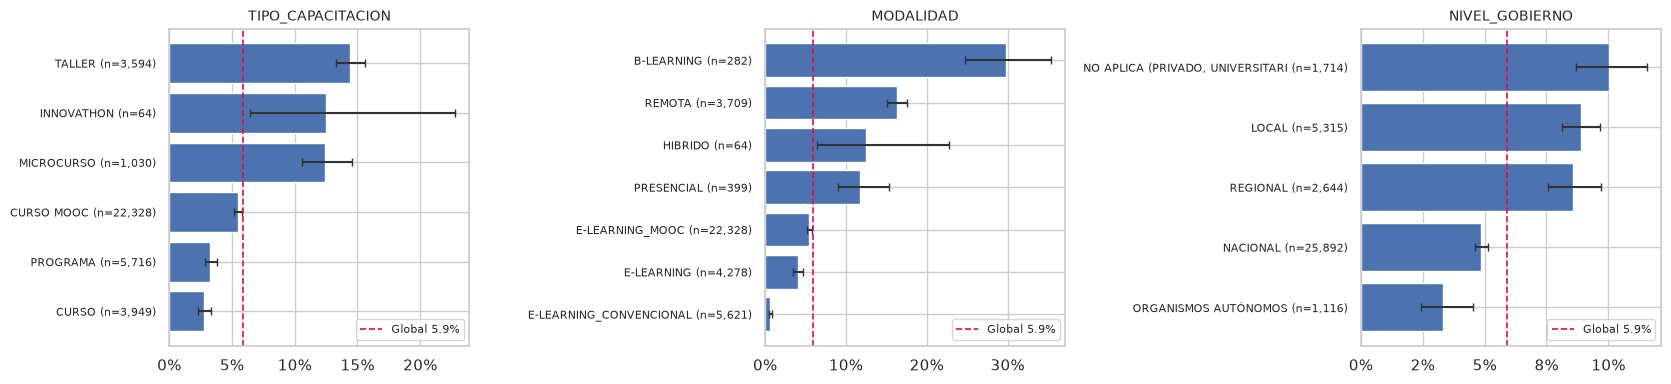

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, col in zip(axes, ["TIPO_CAPACITACION", "MODALIDAD", "NIVEL_GOBIERNO"]):
    graficar_tasas(df_eval, col, ax=ax)
plt.tight_layout()
guardar("06_riesgo_p1")
plt.show()

El riesgo es más alto en b-learning (~29 %, pero solo ~280 personas) y remota (~16 %), y más bajo en e-learning convencional (menos de 1 %). Por tipo, talleres y microcursos pasan del 10 % y cursos y programas rondan 3 %. Local y regional están ~2 puntos por encima de nacional. Además, 80 de los 110 retirados son del grupo «NO APLICA» (privado, universitario, locador).

El riesgo depende más del formato del curso que de quién lo toma.

## 11. Sexo, tipo de convocatoria y departamento

Pregunta: **¿hay diferencias de riesgo entre estos grupos?**

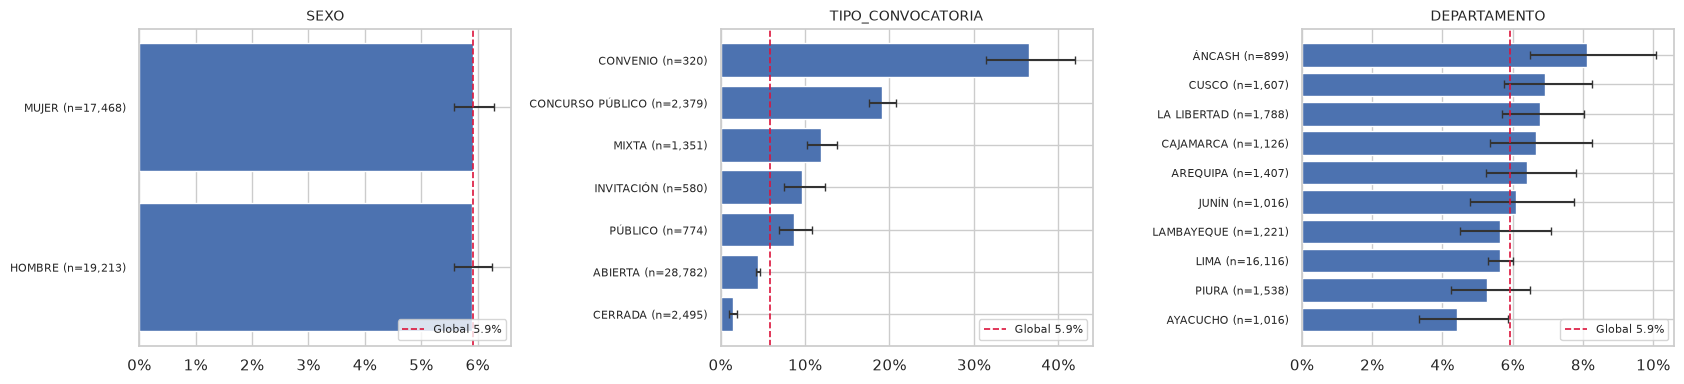

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, col in zip(axes, ["SEXO", "TIPO_CONVOCATORIA", "DEPARTAMENTO"]):
    graficar_tasas(df_eval, col, top=10, min_n=100 if col == "DEPARTAMENTO" else 30, ax=ax)
plt.tight_layout()
guardar("07_riesgo_p2")
plt.show()

Hombres y mujeres tienen casi el mismo riesgo, y el departamento casi no lo cambia. El tipo de convocatoria sí marca diferencias.

Sexo y departamento aportan poco, lo que mueve el riesgo es cómo se convoca y qué curso es. El modelo no puede girar demasiado en torno al departamento o el sexo.

## 12. Horas, duración y mes de inicio

Pregunta: **¿el riesgo cambia con las horas, la duración o el momento del año?**

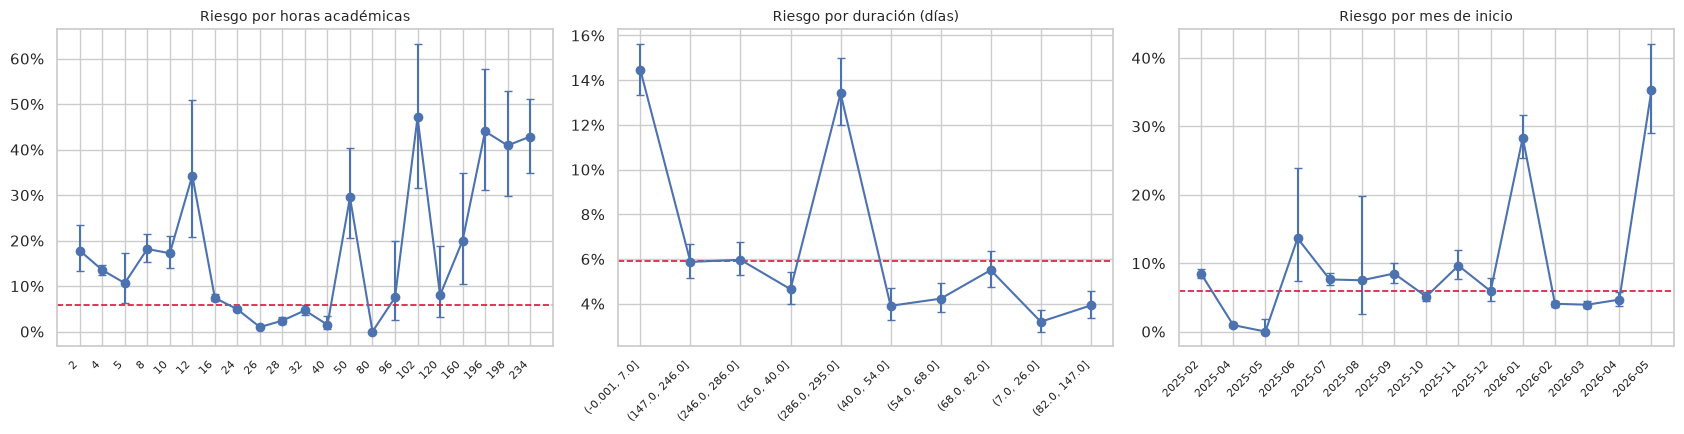

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
graficar_tasas_ordenadas(df_eval, discretizar(df_eval["HORAS_NUM"]), "Riesgo por horas académicas", axes[0])
graficar_tasas_ordenadas(df_eval, discretizar(df_eval["DURACION_DIAS"].where(df_eval["DURACION_DIAS"].between(0, 365))), "Riesgo por duración (días)", axes[1])
graficar_tasas_ordenadas(df_eval, df_eval["MES_INICIO"], "Riesgo por mes de inicio", axes[2])
plt.tight_layout()
guardar("08_riesgo_horas_mes")
plt.show()

Las horas y el mes de inicio se asocian algo más con el riesgo que la duración en días.

Horas, mes y modalidad probablemente reflejan de qué curso se trata (cada curso tiene sus horas y su fecha), no son efectos separados.

# BLOQUE 3 - ¿CAPACITACIÓN O PARTICIPANTE?

## 13. Qué tan agrupados están los datos

Pregunta: **¿unas pocas ediciones concentran el riesgo?**

Ediciones: 198 - mediana de participantes: 76 · máximo: 2,291
El 10 % de las ediciones concentra 57% del riesgo
Variación de la tasa entre ediciones: 0.119 (si todas fueran iguales saldría 0.024)
Out[14]: 
                                                                          n  \
EDICION                                                                       
TRANSFORMACIÓN DIGITAL EN EL PERÚ | 20250217 | 20251123 | E-LEARNIN...  917   
TRANSFORMACIÓN DIGITAL EN EL PERÚ | 20250217 | 20251209 | E-LEARNIN...  602   
VINCULACIÓN MERITOCRÁTICA DE LOS PUESTOS DE CONFIANZA | 20250701 | ...  284   
GESTIÓN PÚBLICA PARA PROMOVER LA IGUALDAD | 20250217 | 20251209 | E...  957   
FUNDAMENTOS PARA EL DISEÑO DE PERFILES DE PUESTOS | 20250701 | 2025...  328   

                                                                          k  \
EDICION                                                                       
TRANSFORMACIÓN DIGITAL EN EL PERÚ | 20250217 | 20251123 | E-LEARNIN...  198   
TRA

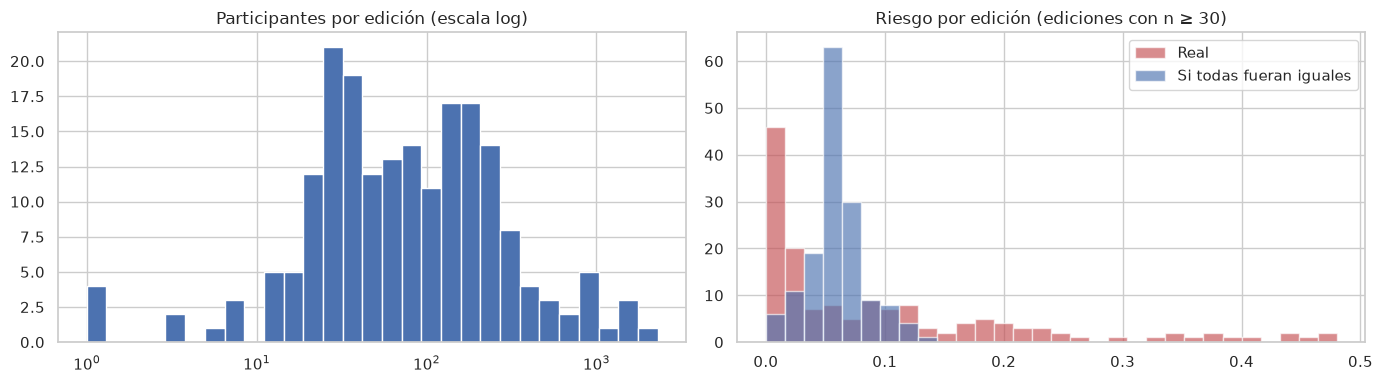

In [14]:
ed = df_eval.groupby("EDICION")["y"].agg(n="size", k="sum")
ed["tasa"] = ed["k"] / ed["n"]
grandes = ed[ed["n"] >= 30]
rng = np.random.default_rng(RANDOM_STATE)
simulada = rng.binomial(grandes["n"].values, TASA_GLOBAL) / grandes["n"].values

orden = ed.sort_values("k", ascending=False)
n10 = max(1, int(len(orden) * 0.10))
print(f"Ediciones: {len(ed)} - mediana de participantes: {ed['n'].median():.0f} · máximo: {ed['n'].max():,}")
print(f"El 10 % de las ediciones concentra {orden['k'].head(n10).sum() / orden['k'].sum():.0%} del riesgo")
print(f"Variación de la tasa entre ediciones: {grandes['tasa'].std():.3f} (si todas fueran iguales saldría {simulada.std():.3f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(ed["n"], bins=np.logspace(0, np.log10(max(ed["n"].max(), 2)), 30), color="#4C72B0")
axes[0].set_xscale("log")
axes[0].set_title("Participantes por edición (escala log)")
bins = np.linspace(0, max(grandes["tasa"].max(), simulada.max(), 0.01), 31)
axes[1].hist(grandes["tasa"], bins=bins, alpha=0.65, color="#C44E52", label="Real")
axes[1].hist(simulada, bins=bins, alpha=0.65, color="#4C72B0", label="Si todas fueran iguales")
axes[1].set_title("Riesgo por edición (ediciones con n ≥ 30)")
axes[1].legend()
plt.tight_layout()
guardar("09_ediciones")
plt.show()

orden.head(5).assign(tasa=lambda t: t["tasa"].round(3))[["n", "k", "tasa"]]

Hay ~200 ediciones, la mediana tiene ~70 personas y la mayor, más de 2 mil. El 10 % de las ediciones concentra ~60 % del riesgo, y el riesgo entre ediciones varía unas 4 veces más de lo que daría el azar.

Unas pocas ediciones (varias MOOC de transformación digital, inteligencia artificial y perfiles de puesto) explican buena parte del riesgo.

## 14. Qué variable pesa más

Pregunta: **¿qué variables se asocian más con el riesgo?** Se mide qué % de las diferencias de resultado queda asociado a cada variable, descontando lo que saldría por azar.

,variable,niveles,eta2,esperado_azar,exceso
0,EDICION,198,0.1544,0.0054,0.1491
1,NOMBRE_CAPACITACION,67,0.1245,0.0018,0.1227
2,HORAS_NUM (agrupada),25,0.0553,0.0007,0.0547
3,TIPO_CONVOCATORIA,7,0.0436,0.0002,0.0435
4,MES_INICIO,15,0.0396,0.0004,0.0392
5,MODALIDAD,7,0.0369,0.0002,0.0368
6,DISTRITO,1013,0.0592,0.0276,0.0316
7,DURACION_DIAS (agrupada),10,0.0226,0.0003,0.0224
8,TIPO_CAPACITACION,6,0.0190,0.0001,0.0189
9,PROVINCIA,232,0.0165,0.0063,0.0102


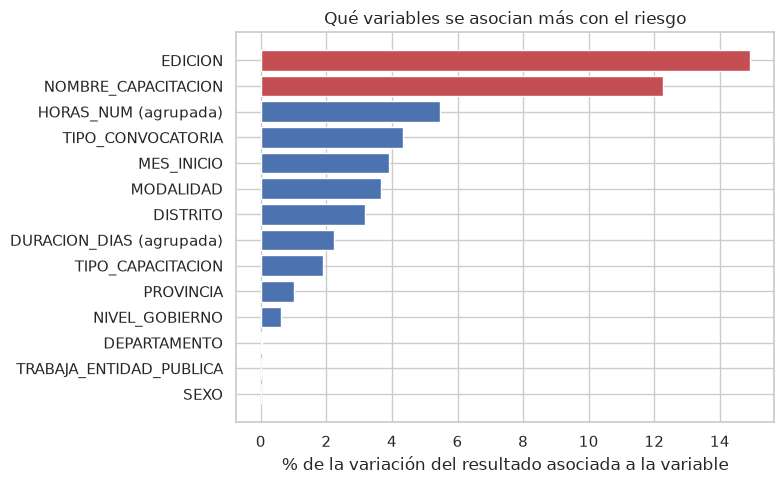

In [15]:
candidatas = ["EDICION", "NOMBRE_CAPACITACION", "MODALIDAD", "TIPO_CAPACITACION", "TIPO_CONVOCATORIA", "NIVEL_GOBIERNO",
              "AREA", "TRABAJA_ENTIDAD_PUBLICA", "DEPARTAMENTO", "PROVINCIA", "DISTRITO", "SEXO", "MES_INICIO"]
filas = []
for c in candidatas:
    e, esp, niv = asociacion(df_eval, c)
    filas.append((c, niv, e, esp, e - esp))
for c in ["HORAS_NUM", "DURACION_DIAS"]:
    d_ = df_eval.assign(_v=discretizar(df_eval[c].where(df_eval[c].between(0, 400)))).dropna(subset=["_v"])
    e, esp, niv = asociacion(d_, "_v")
    filas.append((c + " (agrupada)", niv, e, esp, e - esp))

asoc = pd.DataFrame(filas, columns=["variable", "niveles", "eta2", "esperado_azar", "exceso"]).sort_values("exceso", ascending=False)
display(asoc.round(4).reset_index(drop=True))

a = asoc.dropna(subset=["exceso"]).sort_values("exceso")
plt.figure(figsize=(8, 5))
plt.barh(a["variable"], a["exceso"] * 100, color=["#C44E52" if v in ("EDICION", "NOMBRE_CAPACITACION") else "#4C72B0" for v in a["variable"]])
plt.xlabel("% de la variación del resultado asociada a la variable")
plt.title("Qué variables se asocian más con el riesgo")
plt.tight_layout()
guardar("10_asociacion")
plt.show()

La edición explica ~14 % de las diferencias de resultado y el nombre del curso ~11 %. Siguen horas (~4 %), modalidad (~3 %) y convocatoria (~3 %). Sexo y departamento casi no explican nada. DISTRITO (~3 %) se infla porque tiene miles de categorías.

El resultado depende mucho más de qué capacitación es que de quién la lleva. Las variables tipo, horas y modalidad describen en parte lo mismo que la edición, y esto es por la asociación en estos datos, no capacidad de predicción.

## 15. ¿La diferencia se mantiene dentro de la misma edición?

Pregunta: **¿las diferencias entre grupos son reales o solo reflejan que cada grupo toma cursos distintos?**

In [16]:
def brecha(d, col, a, b, min_n=10):
    sub = d[d[col].isin([a, b])]
    g = sub.groupby(["EDICION", col])["y"].agg(n="size", k="sum").unstack(col)
    if a not in g["n"] or b not in g["n"]:
        return None
    g = g[((g["n"][a] >= min_n) & (g["n"][b] >= min_n)).fillna(False)]
    if g.empty:
        return None
    ra, rb = g["k"][a] / g["n"][a], g["k"][b] / g["n"][b]
    w = g["n"][a] * g["n"][b] / (g["n"][a] + g["n"][b])
    return {"variable": col, "comparación": f"{a} − {b}",
            "brecha_total (pts)": (sub.loc[sub[col] == a, "y"].mean() - sub.loc[sub[col] == b, "y"].mean()) * 100,
            "brecha_dentro_edición (pts)": float(np.average(ra - rb, weights=w)) * 100,
            "ediciones": len(g)}


res = [brecha(df_eval, c, a, b) for c, a, b in
       [("SEXO", "HOMBRE", "MUJER"), ("NIVEL_GOBIERNO", "LOCAL", "NACIONAL"), ("NIVEL_GOBIERNO", "REGIONAL", "NACIONAL")]]
display(pd.DataFrame([r for r in res if r]).round(2))

,variable,comparación,brecha_total (pts),brecha_dentro_edición (pts),ediciones
0,SEXO,HOMBRE − MUJER,-0.02,-0.33,159
1,NIVEL_GOBIERNO,LOCAL − NACIONAL,4.01,2.13,106
2,NIVEL_GOBIERNO,REGIONAL − NACIONAL,3.71,1.18,61


Por sexo no hay diferencia, ni en total ni dentro de la misma edición (menos de medio punto). Local y regional siguen ~1.4–2.1 puntos por encima de nacional incluso comparando dentro de la misma edición.

La diferencia por nivel de gobierno parece real y no un efecto de qué cursos toma cada grupo, por sexo no hay diferencia. Son asociaciones, no causas.

# BLOQUE 4 - CALIDAD DE DATOS Y FUGA DE INFORMACIÓN

Solo detección de problemas

## 16. Chequeos de calidad

Pregunta: **¿qué problemas hay que arreglar antes de modelar?**

In [17]:
n = len(df)
sin_nro = int(df.drop(columns=["NRO"]).duplicated().sum())
checks = pd.DataFrame([
    ("Valores vacíos", int(df.isna().sum().sum())),
    ("Filas idénticas (sin contar NRO)", sin_nro),
    ("Fecha de término anterior al inicio", int((df_temp["TERMINO"] < df_temp["INICIO"]).sum())),
    ("ANO_CAPACITACION distinto del año de inicio", int((df_temp["ANO_NUM"] != df_temp["INICIO"].dt.year).sum())),
    ("Horas nulas o <= 0", int((df_temp["HORAS_NUM"].isna() | (df_temp["HORAS_NUM"] <= 0)).sum())),
], columns=["chequeo", "registros"])
checks["%"] = (checks["registros"] / n * 100).round(2)
display(checks)


def grupos_con_variantes(serie):
    # categorías que son la misma pero escritas distinto (espacios, mayúsculas, tildes)
    mapa = {}
    for v in serie.dropna().astype(str).unique():
        mapa.setdefault(normalizar_texto(v), set()).add(v)
    return sum(len(v) > 1 for v in mapa.values())


variantes = {c: grupos_con_variantes(df[c]) for c in cols_texto}
print("Categorías repetidas por espacios/mayúsculas/tildes (nº de grupos):", {c: v for c, v in variantes.items() if v})

dominante = {c: df[c].value_counts(normalize=True).iloc[0] * 100 for c in df.columns if c != "NRO"}
print("Variables donde un solo valor pasa del 80 %:", {c: round(float(v), 1) for c, v in dominante.items() if v >= 80})

df_temp.loc[df_temp["TERMINO"] < df_temp["INICIO"], ["NOMBRE_CAPACITACION", "FECHA_INICIO", "FECHA_TERMINO"]].drop_duplicates().head(5)

Categorías repetidas por espacios/mayúsculas/tildes (nº de grupos): {'PROVINCIA': 74, 'DISTRITO': 171, 'NIVEL_GOBIERNO': 3, 'TRABAJA_ENTIDAD_PUBLICA': 1, 'NOMBRE_CAPACITACION': 6}
Variables donde un solo valor pasa del 80 %: {'TIPO_DOCUMENTO': 99.3, 'NRO_DOCUMENTO': 100.0, 'BENEFICIARIO': 100.0, 'TRABAJA_ENTIDAD_PUBLICA': 82.8}
Out[17]: 
                                                  NOMBRE_CAPACITACION  \
14584  ÉTICA E INTEGRIDAD PÚBLICA PARA LA PREVENCIÓN DE LA CORRUPCIÓN   

      FECHA_INICIO FECHA_TERMINO  
14584     20250407      20151201  


,chequeo,registros,%
0,Valores vacíos,0,0.00
1,Filas idénticas (sin contar NRO),48444,57.72
2,Fecha de término anterior al inicio,1498,1.78
3,ANO_CAPACITACION distinto del año de inicio,7848,9.35
4,Horas nulas o <= 0,0,0.00


No hay valores nulos, pero sí varios detalles: espacios de más en PROVINCIA (74 grupos), DISTRITO (171), NOMBRE_CAPACITACION (6) y NIVEL_GOBIERNO (3), y NO/No en TRABAJA_ENTIDAD_PUBLICA, 58 % de filas idénticas, 1.8 % con fecha de término anterior al inicio (varias con término en 2015), 9 % con ANO_CAPACITACION distinto del año de inicio; y TIPO_DOCUMENTO es 99 % DNI.

Son arreglos sencillos: normalizar textos y corregir o descartar las fechas raras. Las filas idénticas probablemente son personas distintas con el mismo perfil (la identidad está oculta en el dataset), así que no se borran. TIPO_DOCUMENTO no aporta.

**Resumen de problemas y decisión preliminar**

| Problema | Decisión preliminar |
|---|---|
| Textos con espacios o mayúsculas distintas | Normalizar antes de agrupar |
| Fechas de término anteriores al inicio | Corregir si es evidente (2015 -> 2025) o descartar la fecha |
| `ANO_CAPACITACION` ≠ año de inicio | No usarlo como año de inicio, derivar el año de `FECHA_INICIO` |
| Filas idénticas | No borrar (identidad enmascarada) |
| Eventos/asistencia que no pueden "fallar" | Excluirlos de la población del modelo |
| `TIPO_DOCUMENTO` (99 % DNI) | Descartar |
| `NRO`, `NRO_DOCUMENTO`, `BENEFICIARIO` | Descartar (identificador / enmascarados) |

## 17. ¿Qué variables podrían filtrar el resultado?

El modelo solo debe usar datos que se conozcan **antes** de que la persona empiece.

| Variable | ¿Se conoce al inscribirse? | Comentario |
|---|---|---|
| Sexo, ubicación, nivel de gobierno | Sí | Perfil del participante |
| Tipo, nombre, horas, modalidad, convocatoria | Sí | Características del curso |
| `FECHA_INICIO` | Sí | Calendario |
| `FECHA_TERMINO` / duración | Quizá | Si es la fecha real de cierre, podría reflejar lo que pasó en el curso |
| Tamaño de la edición | Solo al cerrar inscripciones | Se calcula con todos los participantes |
| Riesgo histórico de la edición | No | Usar el riesgo de la propia edición como variable filtraría el resultado |

# BLOQUE 5 - SÍNTESIS

### Lo que se encontró

1. **Más de la mitad del dataset no puede fallar.** Los eventos académicos (y parte de los talleres) solo registran ASISTIÓ. Si modelamos solo las ediciones con evaluación, el riesgo real es cerca de 6 %, no 2.6 %.
2. **El riesgo depende sobre todo de la capacitación** (edición o nombre del curso: ~11–14 %) y poco del participante (sexo y departamento casi no cuentan).
3. Hay más riesgo en **b-learning, remota, talleres y microcursos**, y menos en e-learning convencional, cursos y programas.
4. **Local y regional** tienen ~1.5–2 puntos más de riesgo que nacional, también dentro de la misma edición. El sexo no influye.
5. Los **retirados son pocos (110)**: casi todos de programas largos (82) y del grupo NO APLICA (80).
6. La **calidad** tiene arreglos sencillos, y el período real de las capacitaciones **no es dic-2025 – may-2026** (empiezan desde feb-2025).

### Lo que NO se puede concluir

- Que algo cause el riesgo: son asociaciones en datos administrativos.
- Que esto valga para otros períodos o instituciones.